# Imports

In [7]:
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torchvision.transforms as transforms

from torchvision.models import vgg19
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from PIL import Image
from tqdm import tqdm

# Utils

In [9]:
class ContentLoss(nn.Module):
    """
    Content loss module for neural style transfer.

    Parameters:
        target (torch.Tensor): The target content feature map.

    Attributes:
        loss (torch.Tensor): Content loss value.

    """

    def __init__(self,target=None):
        super(ContentLoss, self).__init__()
        self.loss = None
        if target is not None:
            self.target = target

    def forward(self, input_feature_map):
        """
        Calculate the loss between the input image feature map and the target content feature map.
        Return the input image feature map to maintain the continuity of the model flow.

        Args:
            input_feature_map (torch.Tensor): The input image feature map.

        Returns:
            torch.Tensor: The input image feature map.
        """
        if self.target is not None:
            self.loss = F.mse_loss(input_feature_map, self.target)
        return input_feature_map

def gram_matrix(input):
    a, b, c, d = input.size()
    features = input.view(a * b, c * d)
    G = torch.mm(features, features.t())  # compute the gram product
    return G.div(a * b * c * d)


class StyleLoss(nn.Module):
    """
    Style loss module for neural style transfer.

    Parameters:
        target_feature (torch.Tensor): The target style feature map.

    Attributes:
        loss (torch.Tensor): Style loss value.
        target (torch.Tensor): Gram matrix of the target style feature map.

    """

    def __init__(self,target_feature_map=None, name=None):
        super(StyleLoss, self).__init__()
        self.loss = None
        self.name = name
        if target_feature_map is not None:
            self.target = gram_matrix(target_feature_map)


    def forward(self, input_feature_map):
        """
        Calculate the loss between the Gram matrix of the input image feature map and the target style Gram matrix.
        Return the input image feature map to maintain the continuity of the model flow.

        Args:
            input_feature_map (torch.Tensor): The input image feature map.

        Returns:
            torch.Tensor: The input image feature map.
        """
        if self.target is not None:
            G = gram_matrix(input_feature_map)
            self.loss = F.mse_loss(G, self.target)
        return input_feature_map

class AntiStyle:
    """
    Class for performing anti-style transfer.

    Parameters:
        backbone (torch.nn.Module): The base feature extraction convolutional neural network.
        content_layers (list): List of layer names to be considered for content loss.
        style_layers (list): List of layer names to be considered for style loss.
        content_weight (float): Weight for the content loss.
        style_weight (float): Weight for the style loss.

    Attributes:
        content_layers (list): List of layer names for content loss.
        style_layers (list): List of layer names for style loss.
        content_weight (float): Weight for the content loss.
        style_weight (float): Weight for the style loss.
        model (torch.nn.Module): anti-style transfer model.
        style_losses (list): List of style losses.
        content_losses (list): List of content losses.

    """

    def __init__(self,backbone, content_layers, style_layers, content_weight, style_weight,num_steps):
        self.content_layers = content_layers
        self.style_layers = style_layers
        self.content_weight = content_weight
        self.style_weight = style_weight
        self.num_steps = num_steps
        self.model = None
        self.style_losses = None
        self.content_losses = None
        self.set_base_model(backbone)

    def set_base_model(self,backbone):
        """
        Sets up the base model by trimming unnecessary layers and adding content and style loss layers.

        Args:
            backbone (torch.nn.Module): The base feature extraction convolutional neural network.

        Raises:
            ValueError: If no ContentLoss or StyleLoss layers are found in the model.

        """
        model = nn.Sequential()

        i = 0  # increment every time we see a conv layer.
        for layer in backbone.children():
            if isinstance(layer, nn.Conv2d):
                i += 1
                name = 'conv_{}'.format(i)
            elif isinstance(layer, nn.ReLU):
                name = 'relu_{}'.format(i)
                layer = nn.ReLU(inplace=False)
            elif isinstance(layer, nn.SiLU):
                name = 'silu_{}'.format(i)
                # layer = nn.SiLU(inplace=False)
            elif isinstance(layer, torchvision.ops.StochasticDepth):
                name = 'StochasticDepth_{}'.format(i)
                # layer = torchvision.ops.StochasticDepth(p=0,mode='row')
            elif isinstance(layer, nn.MaxPool2d):
                name = 'pool_{}'.format(i)
            elif isinstance(layer, nn.BatchNorm2d):
                name = 'bn_{}'.format(i)
            else:
                raise RuntimeError('Unrecognized layer: {}'.format(layer.__class__.__name__))

            model.add_module(name, layer)

            # add hidden content loss layer after content layer.
            if name in self.content_layers:
                model.add_module("content_loss_{}".format(i), ContentLoss())

            # add hidden style loss layer after style layer.
            if name in self.style_layers:
                model.add_module("style_loss_{}".format(i), StyleLoss())

        # Find the index of the last content or style loss layer.
        last_loss_layer_index = None
        for i in range(len(model) - 1, -1, -1):
            if isinstance(model[i], (ContentLoss, StyleLoss)):
                last_loss_layer_index = i
                break

        # Check if any content or style loss layers were found.
        if last_loss_layer_index is not None:
            # Trim off layers after the last content or style loss layer.
            trimmed_model = model[:last_loss_layer_index + 1]
            self.model = trimmed_model
        else:
            # Handle the case where no content or style loss layers were found.
            raise ValueError("No ContentLoss or StyleLoss layers found in the model.")

        self.model.eval()
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(device)
        self.model.requires_grad_(False)


    def update_targets(self,content_image, style_image):
        """
        Update the target feature maps for content and style images.

        Args:
            content_image (torch.Tensor): Content image.
            style_image (torch.Tensor): Style image.

        """
        content_losses = []
        style_losses = []

        content_image_tensor = content_image.detach()
        style_img_tensor = style_image.detach()

        i = 0  # increment every time we see a conv layer.
        for layer in self.model.children():
            if isinstance(layer, nn.Conv2d):
                i += 1
                name = 'conv_{}'.format(i)
            elif isinstance(layer, nn.ReLU):
                name = 'relu_{}'.format(i)
            elif isinstance(layer, nn.SiLU):
                name = 'silu_{}'.format(i)
            elif isinstance(layer, torchvision.ops.StochasticDepth):
                name = 'StochasticDepth_{}'.format(i)
            elif isinstance(layer, nn.MaxPool2d):
                name = 'pool_{}'.format(i)
            elif isinstance(layer, nn.BatchNorm2d):
                name = 'bn_{}'.format(i)
            elif isinstance(layer, ContentLoss) or isinstance(layer, StyleLoss):
                continue
            else:
                raise RuntimeError('Unrecognized layer: {}'.format(layer.__class__.__name__))

            content_image_tensor = layer(content_image_tensor).detach()
            style_img_tensor = layer(style_img_tensor).detach()

            # update hidden content loss layers:
            if name in self.content_layers:
                content_loss = ContentLoss(content_image_tensor)
                setattr(self.model, f'content_loss_{i}', content_loss)
                content_losses.append(content_loss)

            # update hidden style loss layers:
            if name in self.style_layers:
                style_loss = StyleLoss(style_img_tensor)
                setattr(self.model, f'style_loss_{i}', style_loss)
                style_losses.append(style_loss)

        self.style_losses = style_losses
        self.content_losses = content_losses

    def apply(self,content_image, style_image, input_img):
        """
        Apply the anti-style transfer to the input image.

        Args:
            content_image (torch.Tensor): Content image.
            style_image (torch.Tensor): Style image.
            input_img (torch.Tensor): Input image to be optimized.

        Returns:
            torch.Tensor: Optimized input image.

        """
        self.update_targets(content_image,style_image)

        input_img.requires_grad_(True)

        optimizer = optim.Adam([input_img])

        def anti_style_step():
            optimizer.zero_grad()
            self.model(input_img)
            style_loss = -sum(sl.loss for sl in self.style_losses)
            style_loss.backward()
            return style_loss

        def content_step():
            optimizer.zero_grad()
            self.model(input_img)
            content_loss = sum(cl.loss for cl in self.content_losses)
            style_loss = -sum(sl.loss for sl in self.style_losses)
            total_loss = content_loss * self.content_weight + style_loss * self.style_weight
            total_loss.backward()
            return total_loss

        # Perform optimization steps.
        for _ in range(0,self.num_steps):
            optimizer.step(anti_style_step)
            optimizer.step(content_step)
            # Clip pixel values to valid range.
            input_img.data.clamp_(0, 1)

        return input_img.detach()

class AntiStyler:

    def __init__(self,backbone, content_layers, style_layers, content_weight, style_weight,num_steps):
        self.anti_style = AntiStyle(backbone, content_layers, style_layers, content_weight, style_weight,num_steps)
        self.image_size = 600
        self.padding = 10
        self.tau = 0.99
        self.thres = 0.5

    def resize(self, image,size):
      return transforms.Resize(size, antialias=True)(image)

    def erode(self, mask, kernel_size=11):
      eroded_mask = F.max_pool2d(1 - mask.float(), kernel_size, stride=1, padding=kernel_size // 2)
      return 1 - eroded_mask

    def dilate(self, mask, kernel_size=11):
        dilated_mask = F.max_pool2d(mask.float(), kernel_size, stride=1, padding=kernel_size // 2)
        return dilated_mask

    def apply_mean_kernel(self, mask, kernel_size=11):
        kernel = torch.ones((1,1, kernel_size, kernel_size), device=mask.device) / (kernel_size * kernel_size)
        mean_filtered_mask = F.conv2d(mask.unsqueeze(0), kernel,padding=kernel_size // 2)
        return mean_filtered_mask.squeeze(0)

    def apply(self, image, device):
      imshow(image, title="Input Image")
      original_size = (image.shape[2], image.shape[3])
      content_image = torch.zeros((1, 3, self.image_size, self.image_size), device=device)
      content_image[:, :, :self.padding, :] = torch.rand((1, 3, self.padding, self.image_size))
      content_image[:, :, -self.padding:, :] = torch.rand((1, 3, self.padding, self.image_size))
      content_image[:, :, :, :self.padding] = torch.rand((1, 3, self.image_size, self.padding))
      content_image[:, :, :, -self.padding:] = torch.rand((1, 3, self.image_size, self.padding))
      content_image[:, :, self.padding:-self.padding, self.padding:-self.padding] = self.resize(image, (self.image_size - 2 * self.padding, self.image_size - 2 * self.padding))

      content_image.to(device, torch.float)
      imshow(content_image, title="Padded Input Image")
      style_image = torch.randn_like(content_image, device=device, dtype=torch.float)
      anti_styled_image = self.anti_style.apply(content_image, style_image, content_image.clone())
      imshow(anti_styled_image, title="AntiStyled Image")

      difference_image = torch.abs(anti_styled_image - content_image)
      difference_image = difference_image.mean(dim=1)
      flattened_values = difference_image.flatten()
      k = int(self.tau * flattened_values.shape[0])
      threshold_value = torch.kthvalue(flattened_values, k, dim=0).values.item()
      difference_image = (difference_image >= threshold_value).float()
      difference_image = difference_image[:, self.padding : -self.padding, self.padding : -self.padding]
      temp = torch.stack([difference_image] * 3, dim=1)
      imshow(temp, title="Raw Mask")

      # Apply erosion and dilation
      difference_image = self.dilate(difference_image)
      difference_image = self.erode(difference_image)
      difference_image = self.apply_mean_kernel(difference_image, kernel_size=51)
      difference_image = (difference_image >= self.thres).float()
      difference_image = self.dilate(difference_image)

      temp = torch.stack([difference_image] * 3, dim=1)
      imshow(temp, title="Final Mask")

      if torch.sum(difference_image).item():
          difference_image = torch.stack([difference_image] * 3, dim=1)
          anti_styled_image = anti_styled_image[:, :, self.padding : -self.padding, self.padding : -self.padding]
          final_image = anti_styled_image - (difference_image * anti_styled_image)
          final_image = self.resize(final_image, original_size)
      else:
          final_image = image

      return final_image

In [10]:
def get_device():
    """
    Get the available computation device.

    Checks whether CUDA (GPU) is available via PyTorch and returns
    the appropriate device object.

    Returns
    -------
    torch.device
        'cuda' if a GPU is available, otherwise 'cpu'.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return device


def imshow(tensor, title=None, detections=None, score_thresh=0.0):
    """
    Display a PyTorch image tensor with optional object detections and title.

    Parameters
    ----------
    tensor : torch.Tensor
        Image tensor of shape (1, C, H, W) or (C, H, W).

    title : str, optional
        Title for the image.

    detections : list[dict], optional
        Detection output (e.g., from Faster R-CNN), where each dict contains:
        'boxes', 'labels', 'scores'.

    score_thresh : float, optional
        Minimum score threshold for displaying detections.

    Returns
    -------
    None
    """

    image = tensor.cpu().squeeze(0).permute(1, 2, 0)
    image = image.clamp(0, 1)  # safer for display

    fig, ax = plt.subplots(1)
    ax.imshow(image)

    # Draw detections if provided
    if detections is not None:
        det = detections[0]  # assuming batch size 1

        boxes = det['boxes'].detach().cpu()
        labels = det['labels'].detach().cpu()
        scores = det['scores'].detach().cpu()

        for box, label, score in zip(boxes, labels, scores):
            if score < score_thresh:
                continue

            x1, y1, x2, y2 = box

            # Draw rectangle
            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            ax.add_patch(rect)

            # Label text
            if class_names is not None:
                label_text = class_names[label]
            else:
                label_text = f"{label.item()}"

            label_text += f": {score:.2f}"

            ax.text(
                x1,
                y1 - 5,
                label_text,
                color='white',
                fontsize=10,
                bbox=dict(facecolor='red', alpha=0.5)
            )

    if title is not None:
        plt.title(title)

    plt.axis('off')
    plt.show()

def load_image(image_path, device, file_type='jpg'):
    """
    Load an image from the given path, convert it to RGB if it's grayscale, and return it as a PyTorch tensor.

    Args:
        image_path (str): The path to the image file.
        device (torch.device): The device to which the image tensor should be moved.
        file_type (str): The file type.

    Returns:
        torch.Tensor: The image as a PyTorch tensor.
    """
    if file_type == 'npy':
        image = np.load(image_path) / 255.0
    else:
        image = Image.open(image_path)
    image_tensor = transforms.ToTensor()(image).unsqueeze(0)
    if image_tensor.shape[1]==1:
        image_tensor = torch.stack([image_tensor.squeeze(0)] * 3,dim=1)
    return image_tensor.to(device, torch.float)

def generate_attack(attack_config):
    """
    Generate an adversarial patch attack for an object detection model.

    This function optimizes a learnable image patch such that, when applied to a fixed
    location in the input image, it induces the detection model to predict a specified
    target object (label + bounding box).

    Parameters
    ----------
    attack_config : dict
        Configuration dictionary containing the following keys:

        - 'image' : torch.Tensor
            Input image tensor of shape (1, C, H, W).

        - 'patch_size' : int
            Size (height and width) of the square adversarial patch.

        - 'lr' : float
            Learning rate for patch optimization.

        - 'num_epochs' : int
            Number of optimization steps.

        - 'detection_model' : torch.nn.Module
            Object detection model (e.g., Faster R-CNN) in training mode.

        - 'target_location' : torch.Tensor
            Target bounding box tensor of shape (1, 4) in (x1, y1, x2, y2) format.

        - 'target_label' : str
            Target class name (must exist in `class_names`).

        - 'device' : torch.device
            Device on which computation is performed (CPU or CUDA).

    Returns
    -------
    torch.Tensor
        The attacked image tensor with the optimized adversarial patch applied.
        Shape: (1, C, H, W)
    """

    # Create learnable patch initialized randomly in [0, 1]
    patch = torch.nn.Parameter(
        torch.rand(1, 3, attack_config['patch_size'], attack_config['patch_size']),
        requires_grad=True
    )

    optimizer = torch.optim.Adam([patch], lr=attack_config['lr'])
    detection_model = attack_config['detection_model']

    # Define target for the detector (supervised attack signal)
    target = [{
        'boxes': attack_config['target_location'],
        'labels': torch.tensor(
            [class_names.index(attack_config['target_label'])],
            dtype=torch.int64,
            device=attack_config['device']
        )
    }]

    # Compute patch placement (bottom-right-ish region)
    min_y = int((attack_config['image'].shape[2] + attack_config['patch_size']) / 2)
    min_x = int((attack_config['image'].shape[3] + attack_config['patch_size']) / 2)

    # Training loop
    for _ in tqdm(range(attack_config['num_epochs'])):
        optimizer.zero_grad()

        # Apply patch to a copy of the image
        attacked_image = torch.clone(attack_config['image'])
        attacked_image[:, :,
                       min_y:min_y + attack_config['patch_size'],
                       min_x:min_x + attack_config['patch_size']] = patch

        # Compute detection loss (forces model toward target prediction)
        model_losses = detection_model(attacked_image, target)
        total_loss = sum(partial_loss for partial_loss in model_losses.values())

        # Backpropagate to update patch
        total_loss.backward(retain_graph=True)
        optimizer.step()

        # Keep patch values valid for image space
        patch.data = torch.clamp(patch.data, 0, 1)

        # Cleanup
        del attacked_image, total_loss
        torch.cuda.empty_cache()

    # Apply final optimized patch
    attacked_image = torch.clone(attack_config['image'])
    attacked_image[:, :,
                   min_y:min_y + attack_config['patch_size'],
                   min_x:min_x + attack_config['patch_size']] = patch

    return attacked_image.detach()

In [11]:
class_names = [
    "__BACKGROUND__",
    "Person", "Bicycle", "Car", "Motorcycle", "Airplane",
    "Bus", "Train", "Truck", "Boat", "Traffic Light",
    "Fire Hydrant", "N/A", "Stop Sign", "Parking Meter", "Bench",
    "Bird", "Cat", "Dog", "Horse", "Sheep", "Cow",
    "Elephant", "Bear", "Zebra", "Giraffe", "N/A",
    "Backpack", "Umbrella", "N/A", "N/A", "Handbag",
    "Tie", "Suitcase", "Frisbee", "Skis", "Snowboard",
    "Sports Ball", "Kite", "Baseball Bat", "Baseball Glove",
    "Skateboard", "Surfboard", "Tennis Racket", "Bottle",
    "N/A", "Wine Glass", "Cup", "Fork", "Knife", "Spoon",
    "Bowl", "Banana", "Apple", "Sandwich", "Orange",
    "Broccoli", "Carrot", "Hot Dog", "Pizza", "Donut",
    "Cake", "Chair", "Couch", "Potted Plant", "Bed",
    "N/A", "Dining Table", "N/A", "N/A", "Toilet",
    "N/A", "TV", "Laptop", "Mouse", "Remote", "Keyboard",
    "Cell Phone", "Microwave", "Oven", "Toaster", "Sink",
    "Refrigerator", "N/A", "Book", "Clock", "Vase",
    "Scissors", "Teddy Bear", "Hair Drier", "Toothbrush"
]

# Demo

**Load Image**

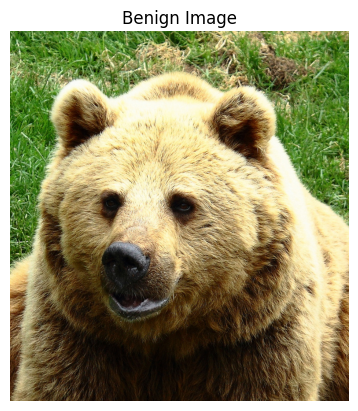

In [12]:
# Set Device
device = get_device()

# Load Image
image_path = "/content/image.jpg"
image = load_image(image_path, device)
imshow(image, "Benign Image")

**Run Object Detection Model on Image**

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 130MB/s]


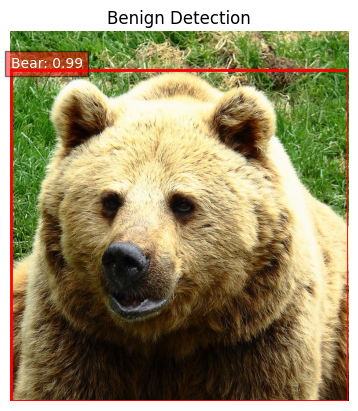

In [13]:
# Load Object Detection Model
detection_model = fasterrcnn_resnet50_fpn(weights='FasterRCNN_ResNet50_FPN_Weights.DEFAULT').eval().to(device)


# Run Object Detection Model on Image and Display Detections
with torch.no_grad():
    detections = detection_model(image)

imshow(image, title="Benign Detection", detections=detections, score_thresh=0.7)

Create Adversarial Image

Generating the Attack


100%|██████████| 200/200 [00:50<00:00,  3.94it/s]


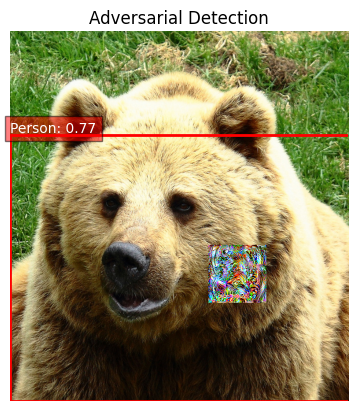

In [14]:
# Generate Attack on Image
attack_config = {
    "image": image,
    "detection_model": detection_model,
    "patch_size" : 100,
    "num_epochs" : 200,
    "target_location": detections[0]['boxes'],
    "target_label": "Person",
    "lr": 0.1,
    "device": device
}

print("Generating the Attack")
attack_config['detection_model'].train()
attacked_image = generate_attack(attack_config)
attack_config['detection_model'].eval()

# Run Object Detection Model on Image and Display Detections
with torch.no_grad():
    detections = detection_model(attacked_image)

imshow(attacked_image, title="Adversarial Detection", detections=detections, score_thresh=0.7)

**Load AntiStyler Defense**

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 111MB/s]


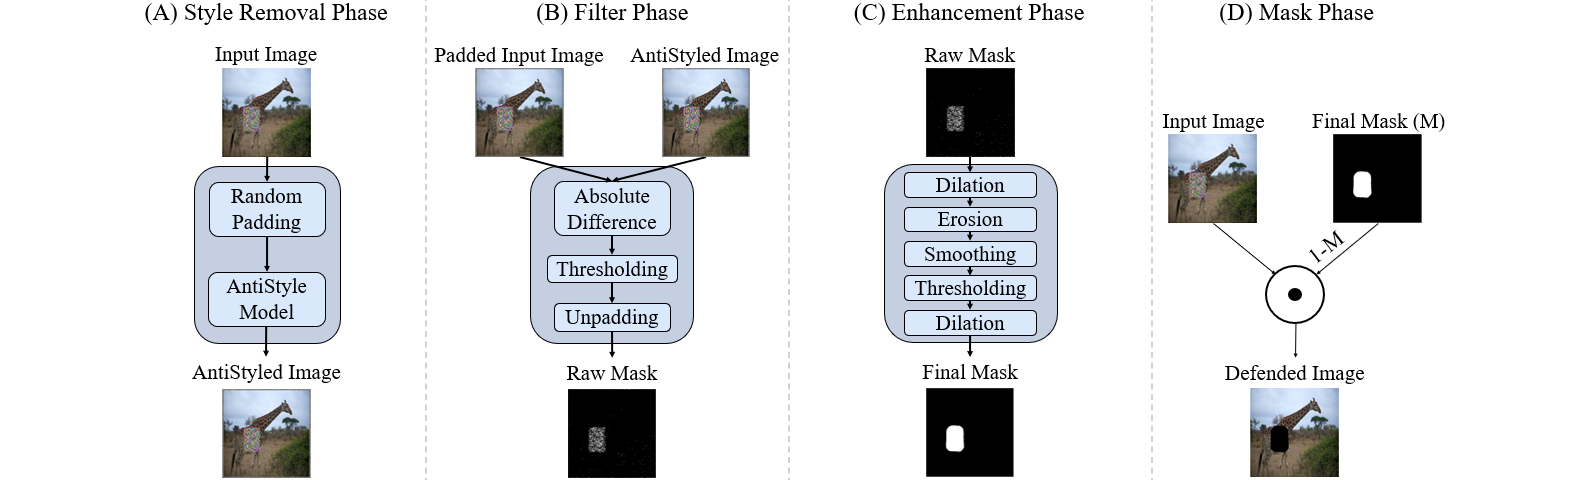

In [15]:
# Set AntiStyler's Hyperparameters
backbone = vgg19(weights='VGG19_Weights.IMAGENET1K_V1').features.eval().to(device)
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']
style_weight = 1000
content_weight = 1
steps = 1
defense = AntiStyler(backbone, content_layers, style_layers, content_weight, style_weight, steps)

from IPython.display import Image, display
display(Image(filename="AntiStyler pipeline.png"))

**Run AntiStyler on Benign Image**

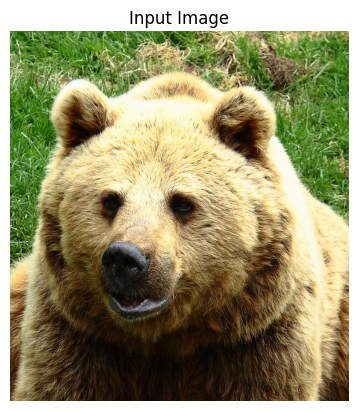

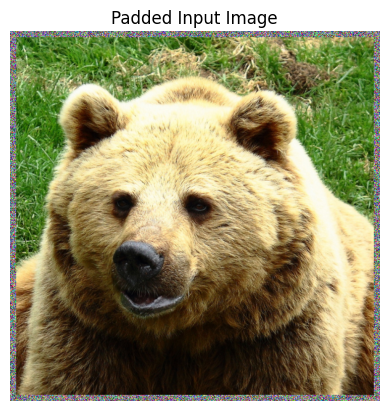

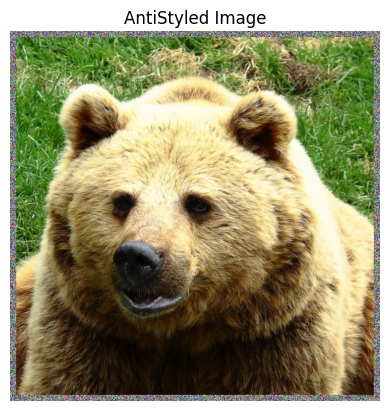

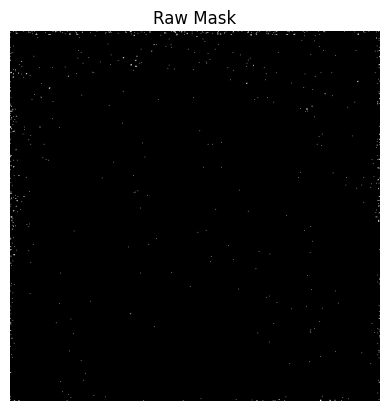

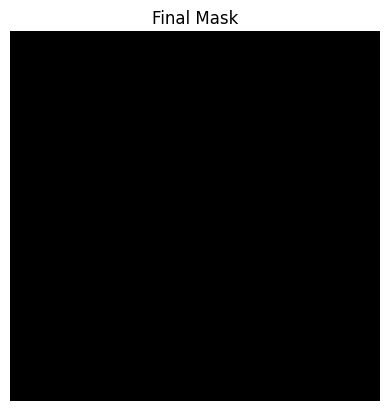

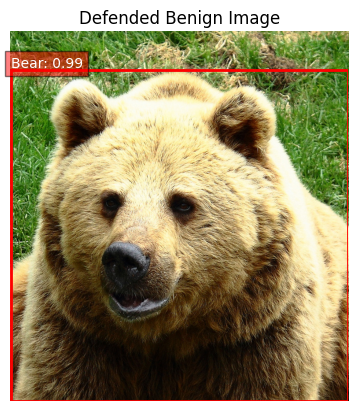

In [16]:
# Apply AntiStyler on Benign Image
defended_image = defense.apply(image, device)

# Run Object Detection Model on Image and Display Detections
with torch.no_grad():
    detections = detection_model(defended_image)

imshow(defended_image, title="Defended Benign Image", detections=detections, score_thresh=0.7)

**Run AntiStyler on Adversarial Image**

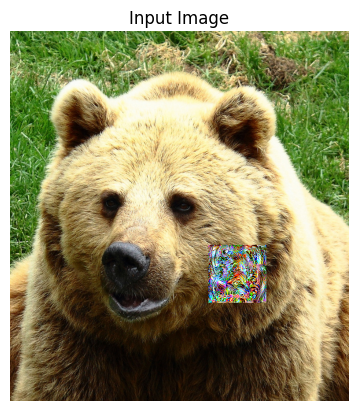

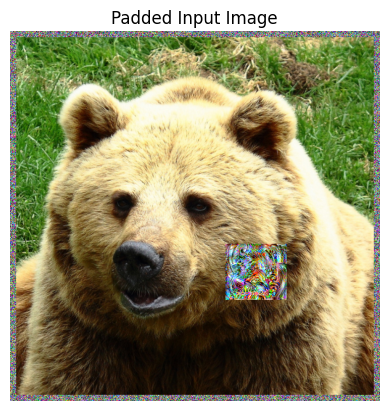

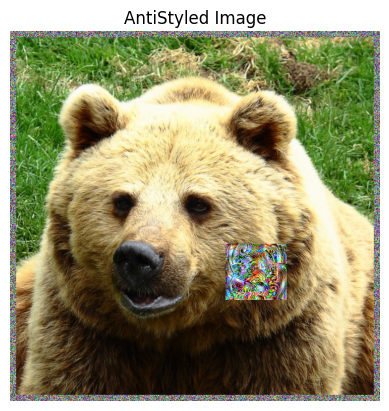

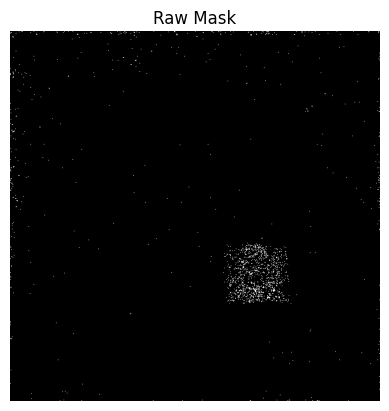

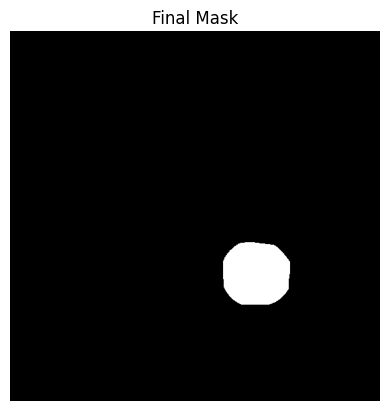

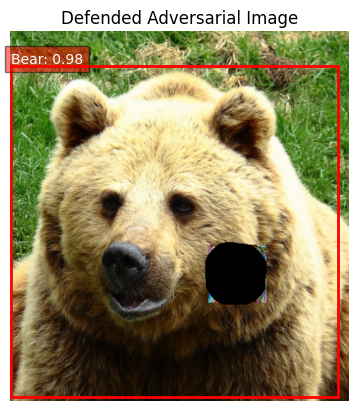

In [17]:
# Apply AntiStyler on Adversarial Image
defended_image = defense.apply(attacked_image, device)

# Run Object Detection Model on Image and Display Detections
with torch.no_grad():
    detections = detection_model(defended_image)

imshow(defended_image, title="Defended Adversarial Image", detections=detections, score_thresh=0.7)

**Main Results**

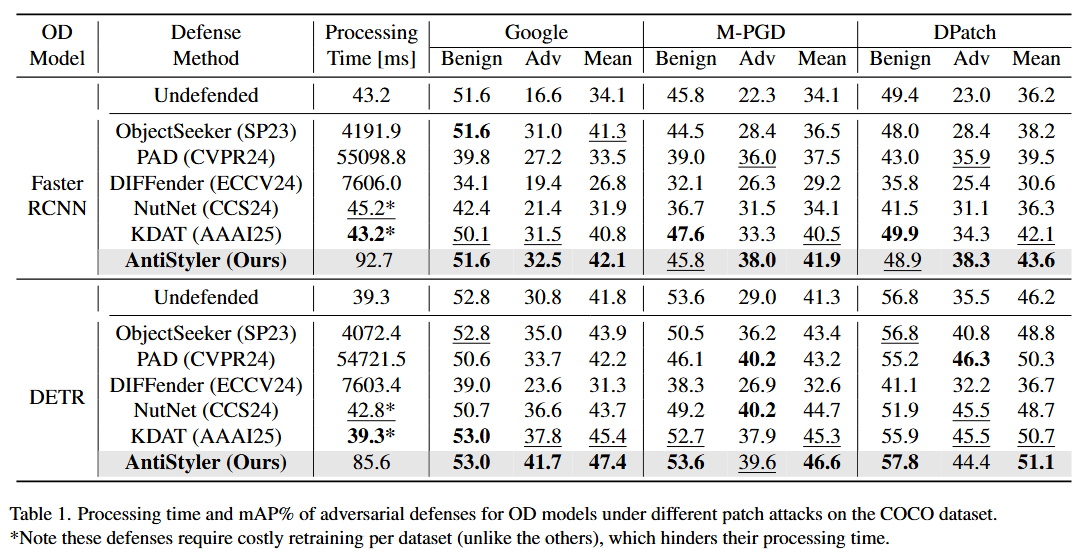

In [18]:
from IPython.display import Image, display
display(Image(filename="AntiStyler results COCO.png"))

In [ ]:
from IPython.display import Image, display
display(Image(filename="AntiStyler results INRIA.png"))